In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import math
from typing import List
import os
import logging

In [ ]:
# ======================= Model ============================
class mySin(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.sin(x)


class NN_mFF(nn.Module):
    def __init__(
        self, input_dim: int = 4, layers: List[int] = [100, 100, 100, 100, 1], sigma=10
    ):
        super().__init__()
        self.input_dim = input_dim
        self.W1 = nn.Parameter(torch.randn(1, layers[0] // 2), requires_grad=True)
        self.W2 = nn.Parameter(torch.randn(1, layers[0] // 2), requires_grad=True)
        self.W3 = nn.Parameter(torch.randn(1, layers[0] // 2), requires_grad=True)
        self.W4 = nn.Parameter(torch.randn(1, layers[0] // 2), requires_grad=True)
        self.layers = self.initialize_NN(layers)

    def initialize_NN(self, layers):
        layers_list = []
        for i in range(len(layers) - 2):
            layers_list.append(nn.Linear(layers[i], layers[i + 1]))
            layers_list.append(mySin())
        layers_list.append(nn.Linear(4 * layers[-2], layers[-1]))
        return nn.Sequential(*layers_list)

    # Forward pass
    def forward(self, H):
        assert H.shape[1] == self.input_dim, "Wrong Input Dim."
        H1 = H[:, 0:1]
        H2 = H[:, 1:2]
        H3 = H[:, 2:3]
        H4 = H[:, 3:4]
        H1 = torch.cat([torch.sin(H1 @ self.W1), torch.cos(H1 @ self.W1)], dim=-1)
        H2 = torch.cat([torch.sin(H2 @ self.W2), torch.cos(H2 @ self.W2)], dim=-1)
        H3 = torch.cat([torch.sin(H3 @ self.W3), torch.cos(H3 @ self.W3)], dim=-1)
        H4 = torch.cat([torch.sin(H4 @ self.W4), torch.cos(H4 @ self.W4)], dim=-1)

        for layer in self.layers[:-1]:
            H1 = layer(H1)
            H2 = layer(H2)
            H3 = layer(H3)
            H4 = layer(H4)
        H = torch.concat([H1, H2, H3, H4], -1)
        H = self.layers[-1](H)  # Dim = 1
        return H

In [3]:
x_mean = np.load(
    "/mnt/01d89e21-2ca4-43ab-baae-fa5833f523c2/4D/4D_ACW/ACW_PINN_4D/(Best)_ACW/x_mean.npy"
)
x_std = np.load(
    "/mnt/01d89e21-2ca4-43ab-baae-fa5833f523c2/4D/4D_ACW/ACW_PINN_4D/(Best)_ACW/x_std.npy"
)

In [4]:
model = NN_mFF()
model.load_state_dict(
    torch.load(
        "/mnt/01d89e21-2ca4-43ab-baae-fa5833f523c2/4D/4D_ACW/ACW_PINN_4D/(Best)_ACW/Best.pt"
    )
)

<All keys matched successfully>

In [5]:
def _u(x):
    assert x.shape[1] == 4, "输入必须是4维空间点"
    u = (
        np.sin(4 * math.pi * x[:, 0:1])
        + np.sin(6 * math.pi * x[:, 1:2])
        + np.sin(8 * math.pi * x[:, 2:3])
        + 0.1 * np.sin(50 * math.pi * x[:, 3:4])
    )
    return u.reshape(-1, 1)

In [ ]:
from pyDOE import lhs

p = torch.tensor(lhs(4, 10000), dtype=torch.float32)
u_true = _u(p).detach().numpy().ravel()
p = (p - torch.tensor(x_mean, dtype=torch.float32)) / torch.tensor(
    x_std, dtype=torch.float32
)
pred = model(p).cpu().detach().numpy().ravel()
rel2 = np.linalg.norm(pred - u_true, 2) / np.linalg.norm(u_true, 2)
print(rel2)

5.618846e-05


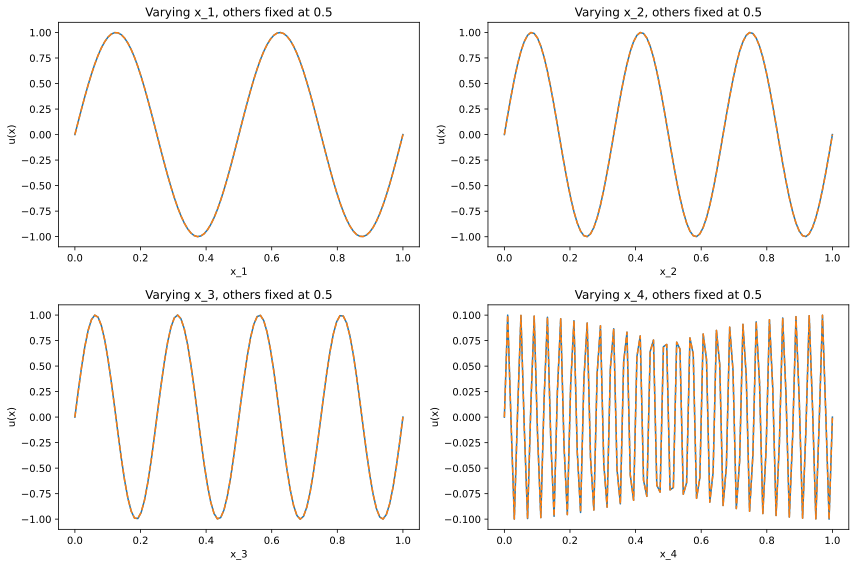

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib_inline import backend_inline

backend_inline.set_matplotlib_formats("svg")


def _u(x):
    assert x.shape[1] == 4, "输入必须是4维空间点"
    u = (
        np.sin(4 * math.pi * x[:, 0:1])
        + np.sin(6 * math.pi * x[:, 1:2])
        + np.sin(8 * math.pi * x[:, 2:3])
        + 0.1 * np.sin(50 * math.pi * x[:, 3:4])
    )
    return u.reshape(-1, 1)


x_vals = np.linspace(0, 1, 100).reshape(-1, 1)

fixed_val = 0.5

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    x_input = np.full((100, 4), fixed_val)
    x_input[:, i] = x_vals.flatten()

    pp = torch.tensor((x_input - x_mean) / x_std, dtype=torch.float32)
    u_vals = _u(x_input).ravel()
    u_pred = model(pp).cpu().detach().numpy().ravel()

    axes[i].plot(x_vals, u_vals, "-")
    axes[i].plot(x_vals, u_pred, "--")
    axes[i].set_title(f"Varying x_{i+1}, others fixed at {fixed_val}")
    axes[i].set_xlabel(f"x_{i+1}")
    axes[i].set_ylabel("u(x)")

plt.tight_layout()
plt.savefig("Ours.pdf")
plt.show()